# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Heart Disease Dataset** dari Kaggle.

Dataset ini berisi data rekam medis pasien yang digunakan untuk memprediksi apakah seseorang menderita penyakit jantung atau tidak (klasifikasi biner).

**Sumber:** [Heart Disease Dataset - Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

**Fitur-fitur utama:**
- `age`: Usia pasien
- `sex`: Jenis kelamin (1 = laki-laki, 0 = perempuan)
- `cp`: Tipe nyeri dada (0-3)
- `trestbps`: Tekanan darah istirahat (mm Hg)
- `chol`: Kolesterol serum (mg/dl)
- `fbs`: Gula darah puasa > 120 mg/dl (1 = ya, 0 = tidak)
- `restecg`: Hasil elektrokardiografi istirahat (0-2)
- `thalach`: Detak jantung maksimum
- `exang`: Angina akibat olahraga (1 = ya, 0 = tidak)
- `oldpeak`: Depresi ST akibat olahraga
- `slope`: Kemiringan segmen ST puncak olahraga
- `ca`: Jumlah pembuluh darah utama (0-3)
- `thal`: Thalassemia
- `target`: Diagnosis penyakit jantung (1 = sakit, 0 = sehat)

# **2. Import Library**

Mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data dan preprocessing.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

Memuat dataset Heart Disease dari file CSV ke dalam DataFrame pandas.

In [3]:
# Download dataset dari Kaggle menggunakan kagglehub
# Pastikan sudah install: pip install kagglehub
# Dan sudah setup Kaggle API key di environment

# Opsi 1: Upload manual di Google Colab
# from google.colab import files
# uploaded = files.upload()

# Opsi 2: Load langsung dari URL (kagglehub)
# !pip install kagglehub -q
# import kagglehub
# path = kagglehub.dataset_download('johnsmith88/heart-disease-dataset')

# Opsi 3: Load dari Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/heart.csv')

# Load dataset (sesuaikan path dengan lokasi file kamu)
df = pd.read_csv('heart.csv')

print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'\n5 baris pertama:')
df.head()

Dataset berhasil dimuat!
Shape: (1025, 14)

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Simpan dataset raw
df.to_csv('heart_raw.csv', index=False)
print('Dataset raw disimpan sebagai heart_raw.csv')

Dataset raw disimpan sebagai heart_raw.csv


# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi mendalam terhadap dataset untuk memahami karakteristik data sebelum preprocessing.

In [5]:
# 4.1 Informasi Dasar Dataset
print('='*50)
print('INFORMASI DASAR DATASET')
print('='*50)
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'\nTipe data setiap kolom:')
print(df.dtypes)
print(f'\nMemori usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

INFORMASI DASAR DATASET
Jumlah baris  : 1025
Jumlah kolom  : 14

Tipe data setiap kolom:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Memori usage: 112.24 KB


In [6]:
# 4.2 Statistik Deskriptif
print('STATISTIK DESKRIPTIF')
print('='*50)
df.describe().T

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [7]:
# 4.3 Cek Missing Values
print('MISSING VALUES')
print('='*50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print('Tidak ada missing values!')

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []
Tidak ada missing values!


In [8]:
# 4.4 Cek Data Duplikat
print('DATA DUPLIKAT')
print('='*50)
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
print(f'Persentase: {(duplicates/len(df))*100:.2f}%')

DATA DUPLIKAT
Jumlah data duplikat: 723
Persentase: 70.54%


DISTRIBUSI TARGET
target
1    526
0    499
Name: count, dtype: int64

Rasio kelas: {1: 0.513, 0: 0.487}


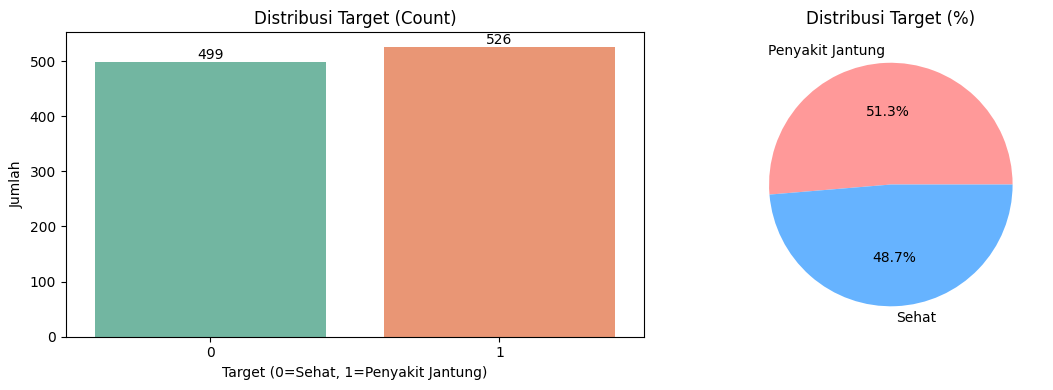

Plot disimpan sebagai target_distribution.png


In [9]:
# 4.5 Distribusi Target (Class Balance)
print('DISTRIBUSI TARGET')
print('='*50)
print(df['target'].value_counts())
print(f'\nRasio kelas: {df["target"].value_counts(normalize=True).round(3).to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Target (Count)')
axes[0].set_xlabel('Target (0=Sehat, 1=Penyakit Jantung)')
axes[0].set_ylabel('Jumlah')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  labels=['Penyakit Jantung', 'Sehat'],
                                  colors=['#ff9999','#66b3ff'])
axes[1].set_title('Distribusi Target (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai target_distribution.png')

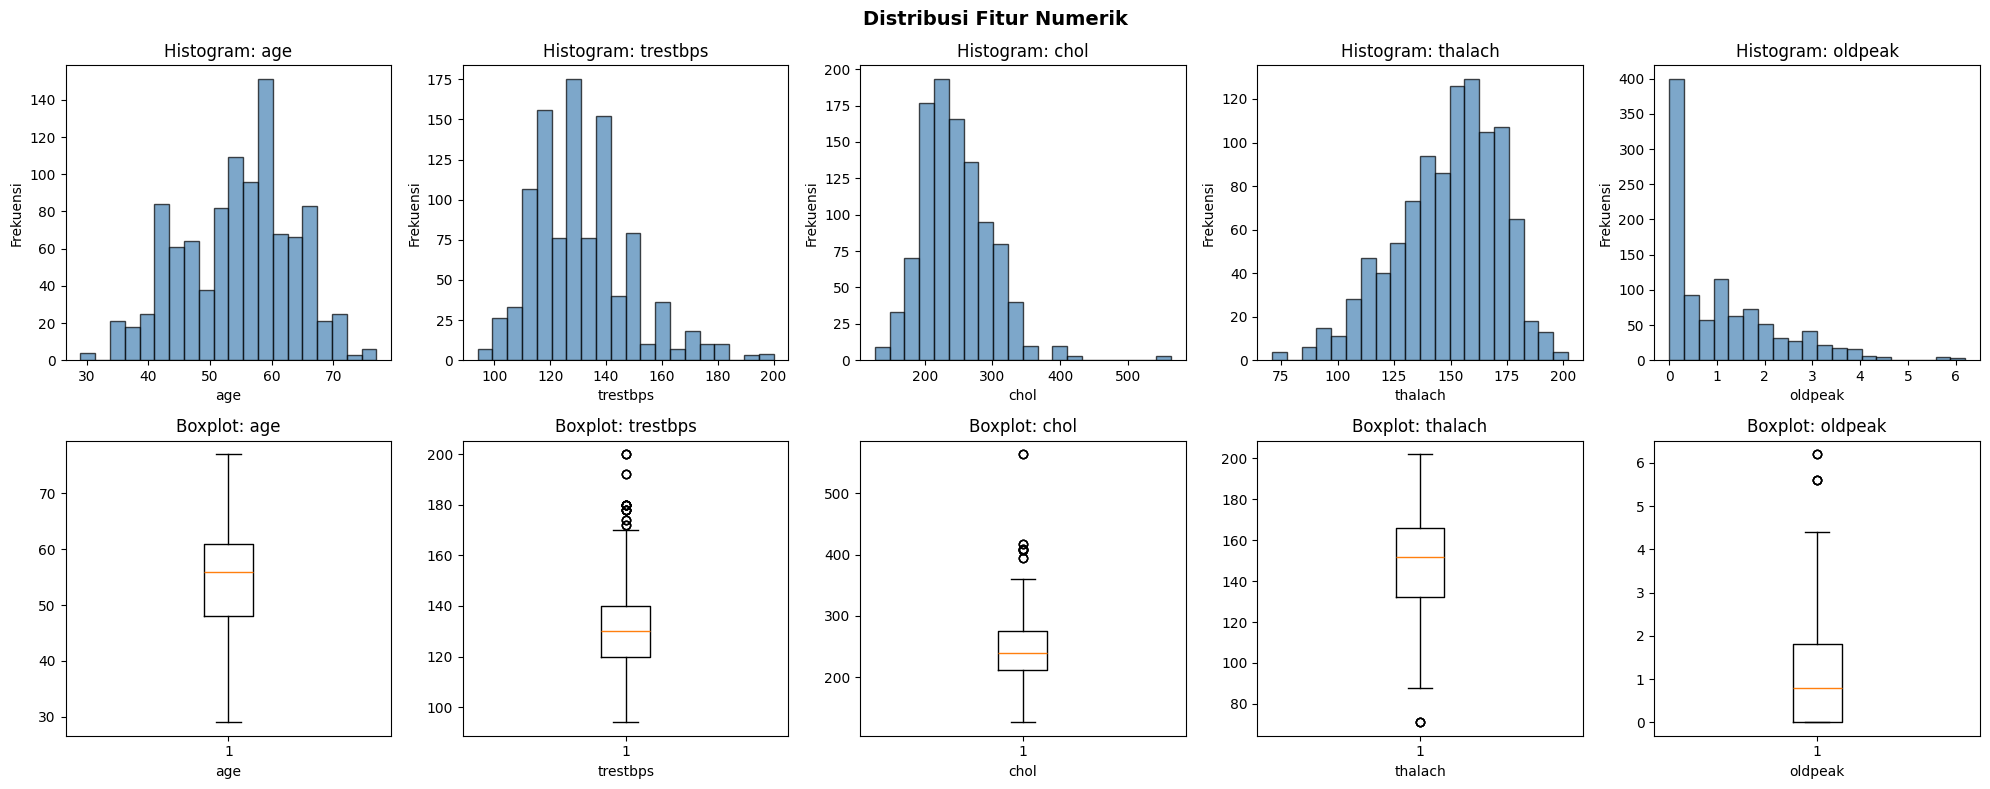

In [10]:
# 4.6 Distribusi Fitur Numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(numerical_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Histogram: {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot
    axes[1, i].boxplot(df[col])
    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_xlabel(col)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

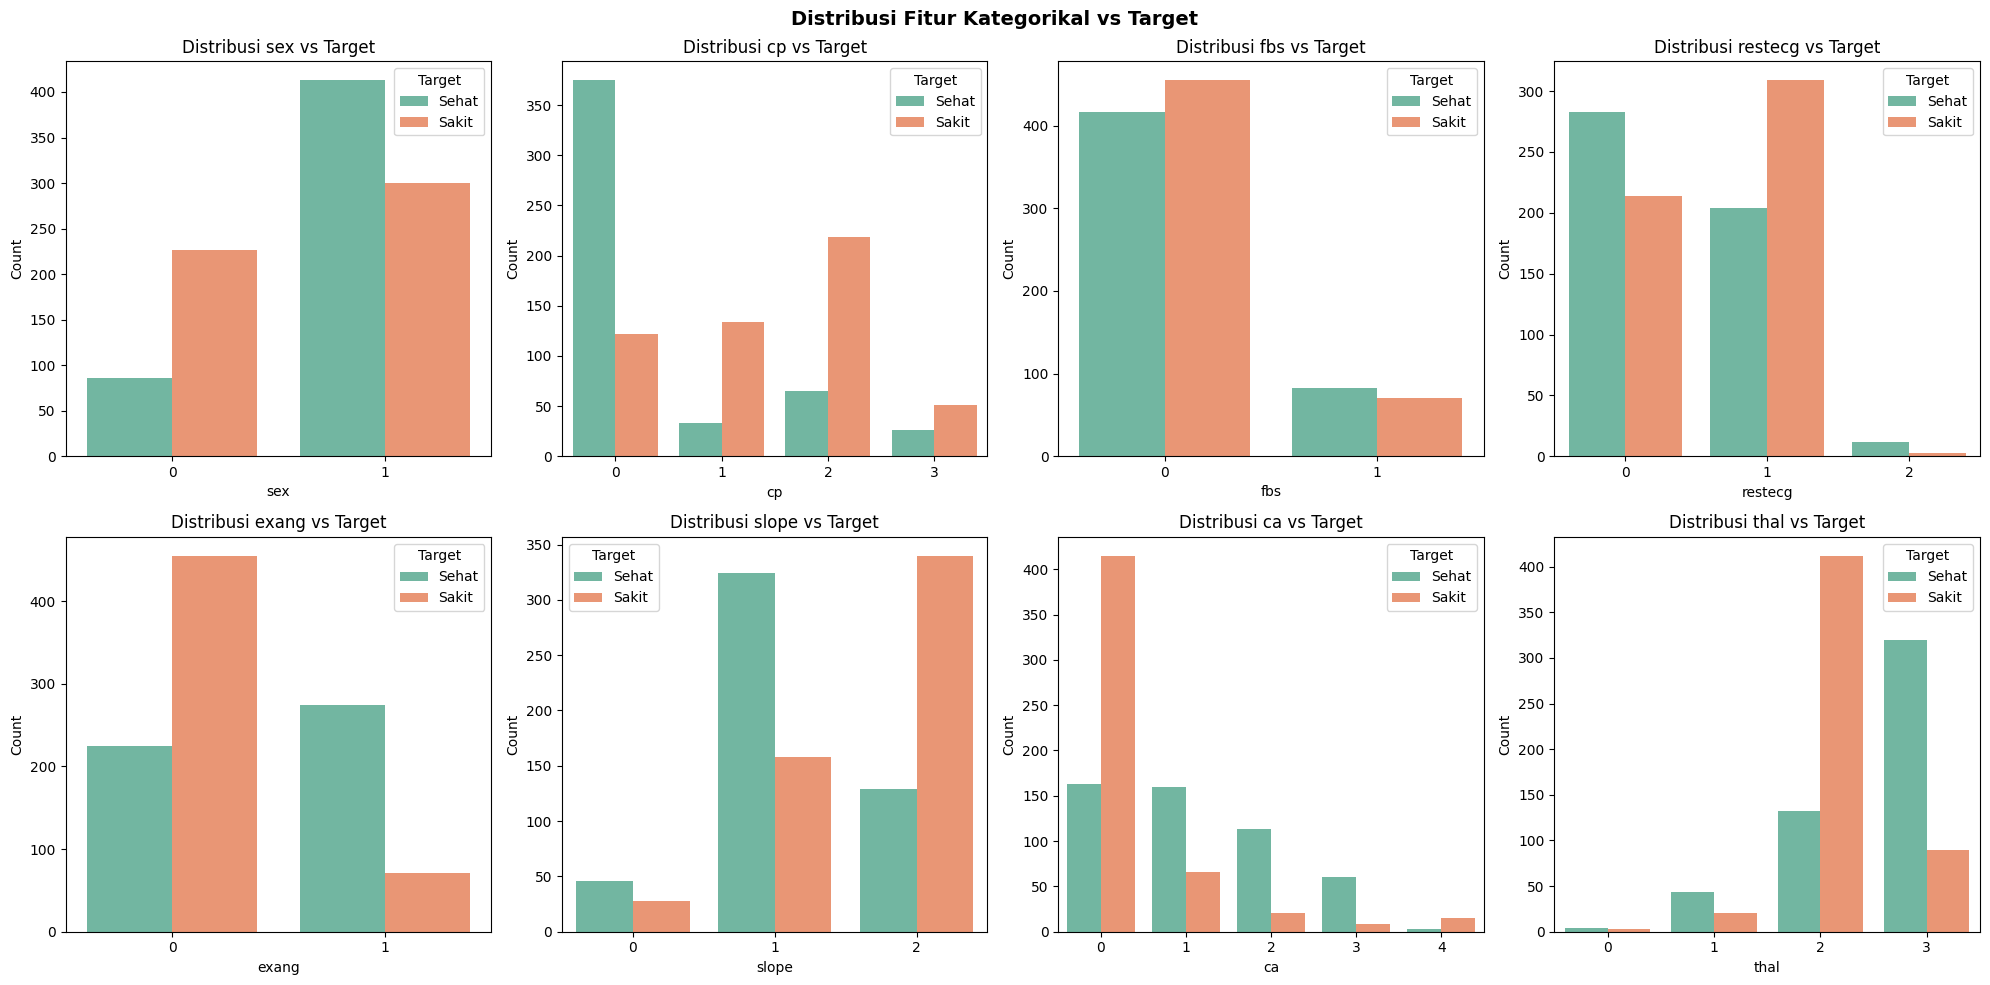

In [11]:
# 4.7 Distribusi Fitur Kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {col} vs Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Target', labels=['Sehat', 'Sakit'])

plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

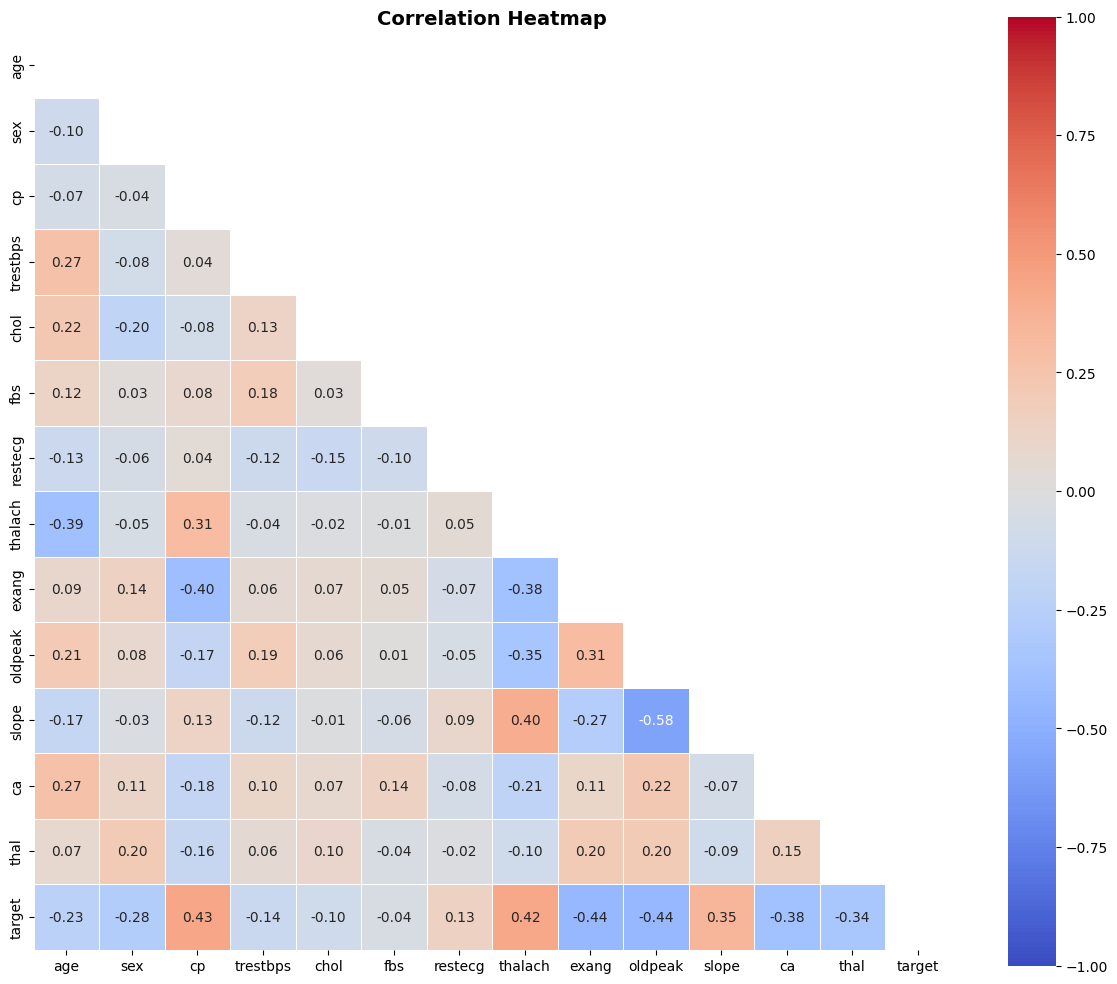


Korelasi dengan Target (diurutkan):
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [12]:
# 4.8 Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Fitur paling berkorelasi dengan target
print('\nKorelasi dengan Target (diurutkan):')
print(corr_matrix['target'].sort_values(ascending=False))

In [13]:
# 4.9 Deteksi Outlier dengan IQR
print('DETEKSI OUTLIER (Metode IQR)')
print('='*50)

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': outliers,
        'Outlier (%)': round((outliers/len(df))*100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

DETEKSI OUTLIER (Metode IQR)
             Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count  \
age        48.0   61.0  13.0         28.5         80.5            0.0   
trestbps  120.0  140.0  20.0         90.0        170.0           30.0   
chol      211.0  275.0  64.0        115.0        371.0           16.0   
thalach   132.0  166.0  34.0         81.0        217.0            4.0   
oldpeak     0.0    1.8   1.8         -2.7          4.5            7.0   

          Outlier (%)  
age              0.00  
trestbps         2.93  
chol             1.56  
thalach          0.39  
oldpeak          0.68  


# **5. Data Preprocessing**

Berdasarkan hasil EDA, berikut tahapan preprocessing yang akan dilakukan:
1. Menghapus data duplikat
2. Menangani missing values (jika ada)
3. Menangani outlier dengan metode IQR capping
4. Encoding fitur kategorikal
5. Normalisasi fitur numerik dengan StandardScaler
6. Split data menjadi train dan test set
7. Menyimpan dataset hasil preprocessing

In [14]:
# 5.1 Hapus Data Duplikat
print('STEP 1: Menghapus Data Duplikat')
print('='*50)
df_clean = df.copy()
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Sebelum : {before} baris')
print(f'Sesudah : {after} baris')
print(f'Dihapus : {before - after} baris duplikat')

STEP 1: Menghapus Data Duplikat
Sebelum : 1025 baris
Sesudah : 302 baris
Dihapus : 723 baris duplikat


In [15]:
# 5.2 Tangani Missing Values
print('STEP 2: Menangani Missing Values')
print('='*50)
missing_count = df_clean.isnull().sum().sum()
if missing_count == 0:
    print('Tidak ada missing values. Tidak perlu penanganan.')
else:
    # Imputasi median untuk numerik, modus untuk kategorikal
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f'  {col}: diisi dengan median ({median_val})')
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f'  {col}: diisi dengan modus ({mode_val})')
print(f'Missing values setelah penanganan: {df_clean.isnull().sum().sum()}')

STEP 2: Menangani Missing Values
Tidak ada missing values. Tidak perlu penanganan.
Missing values setelah penanganan: 0


In [16]:
# 5.3 Tangani Outlier dengan IQR Capping
print('STEP 3: Menangani Outlier (IQR Capping)')
print('='*50)

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_count = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'  {col}: {before_count} outlier di-cap ke [{lower:.2f}, {upper:.2f}]')

print('\nOutlier berhasil ditangani dengan IQR Capping.')

STEP 3: Menangani Outlier (IQR Capping)
  age: 0 outlier di-cap ke [28.50, 80.50]
  trestbps: 9 outlier di-cap ke [90.00, 170.00]
  chol: 5 outlier di-cap ke [115.38, 370.38]
  thalach: 1 outlier di-cap ke [84.12, 215.12]
  oldpeak: 5 outlier di-cap ke [-2.40, 4.00]

Outlier berhasil ditangani dengan IQR Capping.


In [17]:
# 5.4 Encoding Fitur Kategorikal
print('STEP 4: Encoding Fitur Kategorikal')
print('='*50)

# Fitur-fitur yang sudah binary (0/1) tidak perlu di-encode ulang
# Fitur dengan lebih dari 2 nilai unik perlu One-Hot Encoding
multi_cat_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

df_encoded = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=False)

print(f'Shape sebelum encoding : {df_clean.shape}')
print(f'Shape setelah encoding  : {df_encoded.shape}')
print(f'\nKolom baru hasil encoding:')
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(new_cols)

STEP 4: Encoding Fitur Kategorikal
Shape sebelum encoding : (302, 14)
Shape setelah encoding  : (302, 28)

Kolom baru hasil encoding:
['cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


In [18]:
# 5.5 Normalisasi Fitur Numerik (StandardScaler)
print('STEP 5: Normalisasi Fitur Numerik (StandardScaler)')
print('='*50)

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print('Fitur yang dinormalisasi:', numerical_cols)
print('\nStatistik setelah normalisasi:')
print(df_scaled[numerical_cols].describe().round(3))

STEP 5: Normalisasi Fitur Numerik (StandardScaler)
Fitur yang dinormalisasi: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Statistik setelah normalisasi:
           age  trestbps     chol  thalach  oldpeak
count  302.000   302.000  302.000  302.000  302.000
mean    -0.000     0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.814    -2.247   -2.518   -2.881   -0.927
25%     -0.711    -0.679   -0.725   -0.720   -0.927
50%      0.120    -0.076   -0.103    0.127   -0.206
75%      0.728     0.527    0.620    0.721    0.516
max      2.500     2.337    2.637    2.305    2.681


In [19]:
# 5.6 Split Data Train & Test
print('STEP 6: Split Data Train dan Test')
print('='*50)

X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data   : {len(df_scaled)}')
print(f'Data train   : {len(X_train)} ({len(X_train)/len(df_scaled)*100:.1f}%)')
print(f'Data test    : {len(X_test)} ({len(X_test)/len(df_scaled)*100:.1f}%)')
print(f'\nDistribusi target - Train: {y_train.value_counts().to_dict()}')
print(f'Distribusi target - Test : {y_test.value_counts().to_dict()}')

STEP 6: Split Data Train dan Test
Total data   : 302
Data train   : 241 (79.8%)
Data test    : 61 (20.2%)

Distribusi target - Train: {1: 131, 0: 110}
Distribusi target - Test : {1: 33, 0: 28}


In [20]:
# 5.7 Simpan Dataset Hasil Preprocessing
print('STEP 7: Menyimpan Dataset Preprocessed')
print('='*50)

import os
os.makedirs('heart_preprocessing', exist_ok=True)

# Gabungkan X_train + y_train
train_df = X_train.copy()
train_df['target'] = y_train.values
train_df.to_csv('heart_preprocessing/heart_train.csv', index=False)

# Gabungkan X_test + y_test
test_df = X_test.copy()
test_df['target'] = y_test.values
test_df.to_csv('heart_preprocessing/heart_test.csv', index=False)

# Full preprocessed dataset
df_scaled.to_csv('heart_preprocessing/heart_preprocessed.csv', index=False)

print(f'Berhasil disimpan di folder heart_preprocessing/')
print(f'  - heart_train.csv       : {len(train_df)} baris, {len(train_df.columns)} kolom')
print(f'  - heart_test.csv        : {len(test_df)} baris, {len(test_df.columns)} kolom')
print(f'  - heart_preprocessed.csv: {len(df_scaled)} baris, {len(df_scaled.columns)} kolom')
print('\nPreprocessing selesai! ✅')

STEP 7: Menyimpan Dataset Preprocessed
Berhasil disimpan di folder heart_preprocessing/
  - heart_train.csv       : 241 baris, 28 kolom
  - heart_test.csv        : 61 baris, 28 kolom
  - heart_preprocessed.csv: 302 baris, 28 kolom

Preprocessing selesai! ✅
